# MST construction and embedding runtime scaling

This notebook compares exact dense Prim and sparse approximate FAMST **MST graph construction** as the dataset grows. It also compares full two-dimensional t-SNE, UMAP, and IMSTE embedding fits on the same synthetic datasets. The graph-construction chart measures only the MST stage; the embedding chart measures each algorithm's complete fit.

FAMST is approximate. Alongside wall-clock speedup, the notebook reports relative total tree-weight error against Prim wherever the exact run fits the configured memory budget. Install the benchmark dependencies with `python -m pip install -e ".[notebook,famst]"`. The import cell searches the current directory and its parents for the repository. If it cannot find it, install with `python -m pip install -e ".[famst]"` from the repository root.

The timings are machine- and environment-dependent. Warm-up runs for FAMST, UMAP, and IMSTE are excluded. Full embedding runs default to a cap of 30,000 rows; full IMSTE at this size can take a long time.

In [1]:
from time import perf_counter
from pathlib import Path
import platform
import sys
from inspect import signature

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import umap

# Jupyter may start the kernel in the repository root or its notebooks folder.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "imste" / "__init__.py").is_file()),
    None,
)
if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

try:
    from imste import IteratedMinimumSpanningTreeEmbedder
    from imste.mst import build_mst_edges
except ModuleNotFoundError as exc:
    if exc.name != "imste" and not (exc.name or "").startswith("imste."):
        raise
    raise ModuleNotFoundError(
        "Could not locate the IMSTE package. Open this notebook from the "
        "repository, or install it with `python -m pip install -e '.[notebook,famst]'` "
        "from the repository root."
    ) from exc

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"UMAP: {umap.__version__}")

Python: 3.12.13
NumPy: 2.5.3
scikit-learn: 1.9.1
UMAP: 0.5.12


## Benchmark settings

Increase `SAMPLE_SIZES` to explore larger inputs. Exact Prim is skipped when its estimated distance-matrix and packed-edge storage exceeds `EXACT_MEMORY_BUDGET_GB`; this is a guard estimate, not a system memory monitor. Keep `REPEATS` small for larger sizes because exact Prim has quadratic cost. Full t-SNE, UMAP, and IMSTE fits use the same synthetic inputs and are capped at 10,000 rows by default; full IMSTE at this size can take a long time.

In [2]:
# Sample counts for the scaling sweep; synthetic data has 32 input features.
SAMPLE_SIZES = [128, 256, 512, 1_024, 2_048, 4_096, 8_192, 16_384, 30_000, 60_000]
N_FEATURES = 32

# MST graph-construction settings: build 15 trees from a sparse ANN graph.
N_MSTS = 15
ANN_NEIGHBORS = 30
INTER_COMPONENT_EDGES = 5
MAX_ANN_NEIGHBORS = 60

# Repeat each timing twice, with separate seeds for data and algorithm randomness.
REPEATS = 2
DATA_SEED = 42
BENCHMARK_SEED = 123

# Skip exact Prim above this estimated dense-graph memory budget.
EXACT_MEMORY_BUDGET_GB = 7.0

# Full embedding baselines run only through 30,000 rows to bound runtime.
EMBEDDING_MAX_SAMPLES = 10_000
TSNE_ITERATIONS = 500
UMAP_NEIGHBORS = 15
IMSTE_MSTS = 15
IMSTE_EPOCHS = 200  # Explicit IMSTE benchmark budget; the estimator default is 200.
IMSTE_MST_METHOD = 'famst'  # Choose 'prim' to benchmark exact Prim in full fits.

TSNE_ITERATION_PARAMETER = (
    'max_iter' if 'max_iter' in signature(TSNE).parameters else 'n_iter'
)

def make_tsne(random_state):
    return TSNE(
        n_components=2,
        init='pca',
        learning_rate='auto',
        method='barnes_hut',
        random_state=random_state,
        **{TSNE_ITERATION_PARAMETER: TSNE_ITERATIONS},
    )

def estimated_prim_graph_bytes(n_samples):
    # float64 pairwise distances plus the packed edge-availability matrix.
    return n_samples**2 * (8 + 1 / 8)

pd.DataFrame({
    'n_samples': SAMPLE_SIZES,
    'estimated_exact_graph_memory_mb': [
        estimated_prim_graph_bytes(n) / 1024**2 for n in SAMPLE_SIZES
    ],
})

,n_samples,estimated_exact_graph_memory_mb
0,128,0.126953
1,256,0.507812
2,512,2.031250
3,1024,8.125000
4,2048,32.500000
5,4096,130.000000
6,8192,520.000000
7,16384,2080.000000
8,30000,6973.743439
9,60000,27894.973755


## Warm up the backends

FAMST uses PyNNDescent and UMAP uses Numba, which may compile routines on first use. Run small warm-ups for those backends and the IMSTE optimizer; exclude all warm-ups from measured durations.

In [3]:
warmup_X = np.random.default_rng(DATA_SEED).normal(size=(64, N_FEATURES))

_ = build_mst_edges(
    warmup_X, n_msts=N_MSTS, random_state=BENCHMARK_SEED,
    method='prim', neighbors=ANN_NEIGHBORS,
    inter_component_edges=INTER_COMPONENT_EDGES,
    max_neighbors=MAX_ANN_NEIGHBORS,
)
_ = build_mst_edges(
    warmup_X, n_msts=N_MSTS, random_state=BENCHMARK_SEED,
    method='famst', neighbors=ANN_NEIGHBORS,
    inter_component_edges=INTER_COMPONENT_EDGES,
    max_neighbors=MAX_ANN_NEIGHBORS,
)
_ = make_tsne(BENCHMARK_SEED).fit_transform(warmup_X)
_ = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    random_state=BENCHMARK_SEED,
    n_jobs=1,
).fit(warmup_X)
_ = IteratedMinimumSpanningTreeEmbedder(
    n_msts=1, n_epochs=2, random_state=BENCHMARK_SEED,
    mst_method='famst', device='cpu',
).fit_transform(warmup_X)
print('Warm-up complete.')

Warm-up complete.


## Run the MST construction benchmark

Each repeat uses the same dataset for both MST methods. The reported duration is the median across repeats. FAMST's random seed is fixed for repeatability.

In [4]:
records = []

for n_samples in SAMPLE_SIZES:
    X = np.random.default_rng(DATA_SEED + n_samples).normal(
        size=(n_samples, N_FEATURES)
    )
    exact_memory_gb = estimated_prim_graph_bytes(n_samples) / 1024**3
    run_exact = exact_memory_gb <= EXACT_MEMORY_BUDGET_GB

    methods = ['famst', 'prim'] if run_exact else ['famst']
    for method in methods:
        durations = []
        tree_weight = None
        n_edges = None
        for repeat in range(REPEATS):
            started = perf_counter()
            edges, weights = build_mst_edges(
                X, n_msts=N_MSTS,
                random_state=BENCHMARK_SEED + repeat,
                method=method,
                neighbors=ANN_NEIGHBORS,
                inter_component_edges=INTER_COMPONENT_EDGES,
                max_neighbors=MAX_ANN_NEIGHBORS,
            )
            durations.append(perf_counter() - started)
            tree_weight = float(weights.sum())
            n_edges = len(edges)

        records.append({
            'n_samples': n_samples,
            'method': method,
            'median_seconds': float(np.median(durations)),
            'repeat_seconds': durations,
            'tree_weight': tree_weight,
            'n_edges': n_edges,
            'exact_memory_estimate_gb': exact_memory_gb,
            'exact_skipped': not run_exact,
        })

results = pd.DataFrame(records)
results

,n_samples,method,median_seconds,repeat_seconds,tree_weight,n_edges,exact_memory_estimate_gb,exact_skipped
0,128,famst,0.036415,"[0.03956633299821988, 0.0332635419908911]",421.415082,1905,0.000124,False
1,128,prim,0.008078,"[0.008419500023592263, 0.007735542021691799]",421.415082,1905,0.000124,False
2,256,famst,0.033787,"[0.03181741602020338, 0.03575616702437401]",846.148393,3825,0.000496,False
3,256,prim,0.017697,"[0.018587041995488107, 0.01680779195157811]",846.148393,3825,0.000496,False
4,512,famst,0.038862,"[0.03862933401251212, 0.03909533395199105]",1695.615016,7665,0.001984,False
5,512,prim,0.039135,"[0.04033029096899554, 0.03793941700132564]",1695.615016,7665,0.001984,False
6,1024,famst,0.048924,"[0.048452041985001415, 0.04939562501385808]",3394.548260,15345,0.007935,False
7,1024,prim,0.093550,"[0.09406762500293553, 0.09303216601256281]",3394.548260,15345,0.007935,False
8,2048,famst,0.066942,"[0.06793958297930658, 0.06594470801064745]",6792.414749,30705,0.031738,False
9,2048,prim,0.250880,"[0.2588771249866113, 0.2428819999913685]",6792.414749,30705,0.031738,False


## Run full embedding runtime baselines

Each method returns a two-dimensional embedding for the same input matrix. t-SNE uses scikit-learn's Barnes-Hut method with `TSNE_ITERATIONS`; UMAP uses `UMAP_NEIGHBORS` neighbors and a fixed seed; IMSTE uses `IMSTE_MST_METHOD`, `IMSTE_MSTS` trees, and `IMSTE_EPOCHS` optimization epochs. The builder setting defaults to FAMST and can be changed to `prim`. All runs use CPU execution and report the median across `REPEATS`. Sizes above `EMBEDDING_MAX_SAMPLES` are skipped.


In [5]:
embedding_records = []

for n_samples in SAMPLE_SIZES:
    if n_samples > EMBEDDING_MAX_SAMPLES:
        continue
    X = np.random.default_rng(DATA_SEED + n_samples).normal(
        size=(n_samples, N_FEATURES)
    )

    for method in ('tsne', 'umap', 'imste'):
        durations = []
        for repeat in range(REPEATS):
            seed = BENCHMARK_SEED + repeat
            started = perf_counter()
            if method == 'tsne':
                _ = make_tsne(seed).fit_transform(X)
            elif method == 'umap':
                _ = umap.UMAP(
                    n_components=2,
                    n_neighbors=UMAP_NEIGHBORS,
                    random_state=seed,
                    n_jobs=1,
                ).fit_transform(X)
            else:
                _ = IteratedMinimumSpanningTreeEmbedder(
                    n_components=2,
                    n_msts=IMSTE_MSTS,
                    n_epochs=IMSTE_EPOCHS,
                    random_state=seed,
                    mst_method=IMSTE_MST_METHOD,
                    mst_neighbors=ANN_NEIGHBORS,
                    mst_inter_component_edges=INTER_COMPONENT_EDGES,
                    mst_max_neighbors=MAX_ANN_NEIGHBORS,
                    device='cpu',
                ).fit_transform(X)
            durations.append(perf_counter() - started)

        embedding_records.append({
            'n_samples': n_samples,
            'method': method,
            'mst_method': IMSTE_MST_METHOD if method == 'imste' else None,
            'median_seconds': float(np.median(durations)),
            'repeat_seconds': durations,
        })

embedding_results = pd.DataFrame(embedding_records)
embedding_results

,n_samples,method,mst_method,median_seconds,repeat_seconds
0,128,tsne,NaN,0.243281,"[0.27973212499637157, 0.20682924997527152]"
1,128,umap,NaN,0.103330,"[0.12344604200916365, 0.08321379194967449]"
2,128,imste,famst,0.069235,"[0.0717270839959383, 0.06674275000113994]"
3,256,tsne,NaN,0.250386,"[0.2503733340417966, 0.2503993330174126]"
4,256,umap,NaN,0.187588,"[0.1820630410220474, 0.19311283301794901]"
5,256,imste,famst,0.097474,"[0.09855475003132597, 0.09639304102165624]"
6,512,tsne,NaN,0.300269,"[0.30534004099899903, 0.29519745899597183]"
7,512,umap,NaN,0.388379,"[0.3937743750284426, 0.38298441702499986]"
8,512,imste,famst,0.160560,"[0.15842125000199303, 0.16269824997289106]"
9,1024,tsne,NaN,0.530102,"[0.5375646249740385, 0.5226398750091903]"


## Measure additional peak memory

Each backend runs in a fresh subprocess. The worker warms up FAMST first, then samples resident memory during graph construction. The plot shows peak increase above the process baseline (after imports and input creation), so unrelated notebook history does not affect the comparison. Prim is omitted for sizes beyond the exact-memory guard.

In [6]:
import json
import subprocess
import sys

MEMORY_WORKER = r'''
import gc
import json
import sys
import threading
import time

import numpy as np
import psutil

repo_root, method, n_samples, n_features, data_seed, benchmark_seed, n_msts, neighbors, inter_edges, max_neighbors = sys.argv[1:]
n_samples = int(n_samples)
n_features = int(n_features)
if repo_root:
    sys.path.insert(0, repo_root)
from imste.mst import build_mst_edges

# Compile FAMST kernels before measuring the working-set increase.
if method == "famst":
    warmup = np.random.default_rng(123).normal(size=(64, n_features))
    build_mst_edges(warmup, n_msts=1, random_state=123, method=method,
                    neighbors=int(neighbors), inter_component_edges=int(inter_edges),
                    max_neighbors=int(max_neighbors))
    del warmup
    gc.collect()

X = np.random.default_rng(int(data_seed) + n_samples).normal(
    size=(n_samples, n_features)
)
process = psutil.Process()
baseline = process.memory_info().rss
peak = [baseline]
stop = threading.Event()
def sample_memory():
    while not stop.is_set():
        peak[0] = max(peak[0], process.memory_info().rss)
        time.sleep(0.005)
monitor = threading.Thread(target=sample_memory, daemon=True)
monitor.start()
try:
    edges, weights = build_mst_edges(
        X, n_msts=int(n_msts), random_state=int(benchmark_seed),
        method=method, neighbors=int(neighbors),
        inter_component_edges=int(inter_edges),
        max_neighbors=int(max_neighbors),
    )
finally:
    stop.set()
    monitor.join()
peak[0] = max(peak[0], process.memory_info().rss)
print(json.dumps({"peak_working_set_mb": (peak[0] - baseline) / 1024**2,
                  "peak_process_rss_mb": peak[0] / 1024**2,
                  "n_edges": len(edges)}))
'''

memory_records = []
root_arg = str(repo_root) if repo_root is not None else ""
for n_samples in SAMPLE_SIZES:
    exact_allowed = estimated_prim_graph_bytes(n_samples) <= EXACT_MEMORY_BUDGET_GB * 1024**3
    methods = ["famst", "prim"] if exact_allowed else ["famst"]
    for method in methods:
        command = [
            sys.executable, "-c", MEMORY_WORKER, root_arg, method,
            str(n_samples), str(N_FEATURES), str(DATA_SEED),
            str(BENCHMARK_SEED), str(N_MSTS), str(ANN_NEIGHBORS),
            str(INTER_COMPONENT_EDGES), str(MAX_ANN_NEIGHBORS),
        ]
        completed = subprocess.run(command, check=True, capture_output=True, text=True)
        worker_result = json.loads(completed.stdout.strip().splitlines()[-1])
        memory_records.append({
            "n_samples": n_samples,
            "method": method,
            **worker_result,
        })

memory_results = pd.DataFrame(memory_records)
memory_results[["n_samples", "method", "peak_working_set_mb", "peak_process_rss_mb"]]


,n_samples,method,peak_working_set_mb,peak_process_rss_mb
0,128,famst,0.734375,576.265625
1,128,prim,0.609375,344.531250
2,256,famst,0.703125,580.640625
3,256,prim,1.109375,333.875000
4,512,famst,71.468750,644.843750
5,512,prim,4.109375,348.359375
6,1024,famst,3.828125,674.515625
7,1024,prim,11.437500,355.718750
8,2048,famst,11.984375,684.468750
9,2048,prim,41.890625,385.984375


## Compare runtime and approximate-tree weight

The first runtime chart compares MST graph-construction durations. The second compares full embedding-fit durations for t-SNE, UMAP, and IMSTE; IMSTE's fit includes graph construction with `IMSTE_MST_METHOD` and `IMSTE_EPOCHS` epochs of coordinate optimization. Speedup is `Prim time / FAMST time`; values above 1 mean FAMST was faster. Relative weight error compares total edge lengths for the same dataset and does not measure whether selected edges are identical.


In [7]:
wide = results.pivot(index='n_samples', columns='method', values='median_seconds')
summary = pd.DataFrame(index=wide.index)
summary['prim_seconds'] = wide.get('prim')
summary['famst_seconds'] = wide.get('famst')
embedding_wide = embedding_results.pivot(
    index='n_samples', columns='method', values='median_seconds'
)
summary['tsne_seconds'] = embedding_wide.get('tsne')
summary['umap_seconds'] = embedding_wide.get('umap')
summary['imste_seconds'] = embedding_wide.get('imste')
memory_wide = memory_results.pivot(index='n_samples', columns='method', values='peak_working_set_mb')
summary['prim_peak_working_set_mb'] = memory_wide.get('prim')
summary['famst_peak_working_set_mb'] = memory_wide.get('famst')
summary['prim_over_famst_memory_ratio'] = (
    summary['prim_peak_working_set_mb'] / summary['famst_peak_working_set_mb']
)
summary['speedup_prim_over_famst'] = (
    summary['prim_seconds'] / summary['famst_seconds']
)
weights = results.pivot(index='n_samples', columns='method', values='tree_weight')
if {'prim', 'famst'}.issubset(weights.columns):
    summary['famst_relative_weight_error_pct'] = (
        100 * (weights['famst'] - weights['prim']) / weights['prim']
    )
summary

,prim_seconds,famst_seconds,tsne_seconds,umap_seconds,imste_seconds,prim_peak_working_set_mb,famst_peak_working_set_mb,prim_over_famst_memory_ratio,speedup_prim_over_famst,famst_relative_weight_error_pct
n_samples,,,,,,,,,,
128,0.008078,0.036415,0.243281,0.103330,0.069235,0.609375,0.734375,0.829787,0.221819,0.0
256,0.017697,0.033787,0.250386,0.187588,0.097474,1.109375,0.703125,1.577778,0.523797,0.0
512,0.039135,0.038862,0.300269,0.388379,0.160560,4.109375,71.468750,0.057499,1.007012,0.0
1024,0.093550,0.048924,0.530102,0.919949,0.273101,11.437500,3.828125,2.987755,1.912154,0.0
2048,0.250880,0.066942,0.764476,2.415608,0.511920,41.890625,11.984375,3.495437,3.747707,0.0
4096,0.754194,0.107012,1.292400,2.736009,1.027258,151.484375,35.187500,4.305062,7.047773,0.0
8192,2.406988,0.190571,3.825317,5.523554,2.074091,586.609375,77.890625,7.531194,12.630377,0.0
16384,9.089571,0.367531,NaN,NaN,NaN,2225.171875,163.140625,13.639594,24.731441,0.0
30000,56.248278,0.677073,NaN,NaN,NaN,7588.218750,235.000000,32.290293,83.075620,0.0


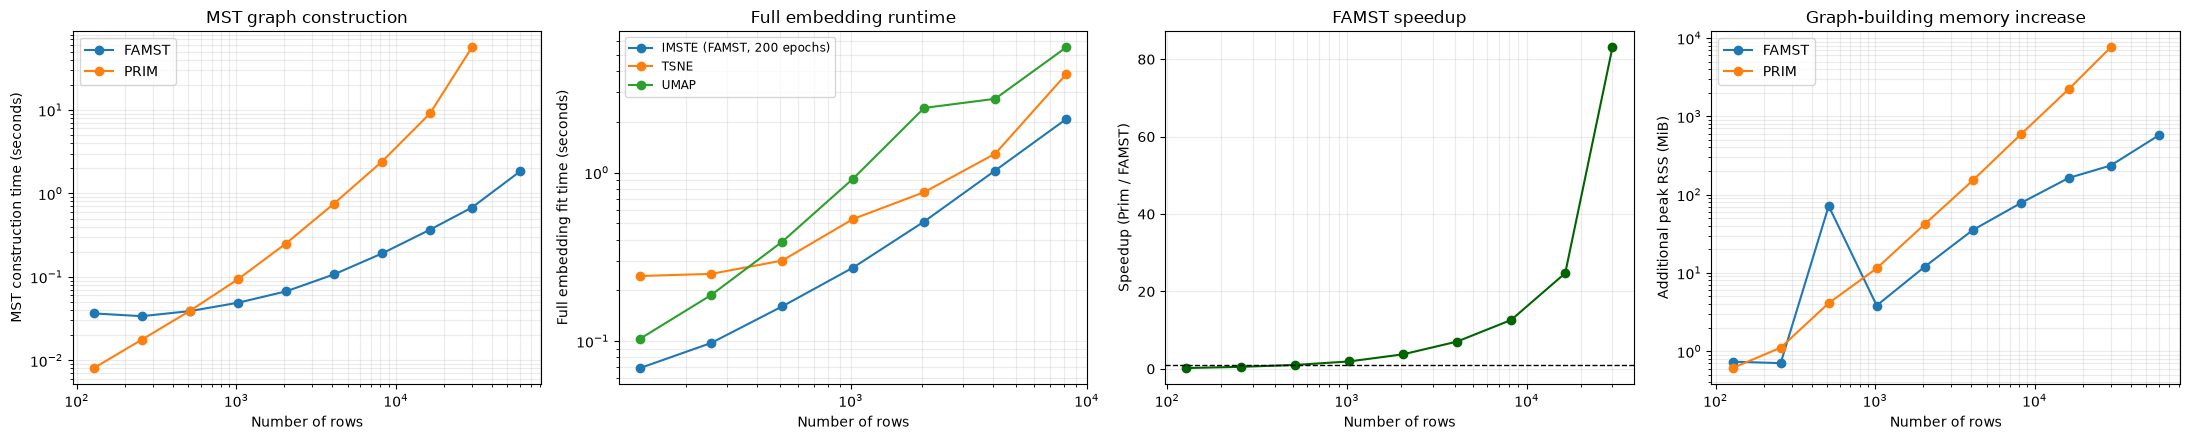

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

for method, group in results.groupby('method'):
    axes[0].plot(
        group['n_samples'], group['median_seconds'],
        marker='o', label=method.upper(),
    )
axes[0].set(xscale='log', yscale='log', xlabel='Number of rows',
            ylabel='MST construction time (seconds)',
            title='MST graph construction')
axes[0].grid(True, which='both', alpha=0.25)
axes[0].legend()

for method, group in embedding_results.groupby('method'):
    label = (
        f'IMSTE ({IMSTE_MST_METHOD.upper()}, {IMSTE_EPOCHS} epochs)'
        if method == 'imste' else method.upper()
    )
    axes[1].plot(
        group['n_samples'], group['median_seconds'],
        marker='o', label=label,
    )
axes[1].set(xscale='log', yscale='log', xlabel='Number of rows',
            ylabel='Full embedding fit time (seconds)',
            title='Full embedding runtime')
axes[1].grid(True, which='both', alpha=0.25)
axes[1].legend(fontsize='small')

available_speedups = summary['speedup_prim_over_famst'].dropna()
axes[2].plot(available_speedups.index, available_speedups,
             marker='o', color='darkgreen')
axes[2].axhline(1, color='black', linewidth=1, linestyle='--')
axes[2].set(xscale='log', xlabel='Number of rows',
            ylabel='Speedup (Prim / FAMST)', title='FAMST speedup')
axes[2].grid(True, which='both', alpha=0.25)
for method, group in memory_results.groupby('method'):
    axes[3].plot(group['n_samples'], group['peak_working_set_mb'],
                 marker='o', label=method.upper())
axes[3].set(xscale='log', yscale='log', xlabel='Number of rows',
            ylabel='Additional peak RSS (MiB)',
            title='Graph-building memory increase')
axes[3].grid(True, which='both', alpha=0.25)
axes[3].legend()
plt.tight_layout()
plt.show()

## Interpretation

- At small sizes, ANN indexing and component handling can outweigh the savings from avoiding a dense distance matrix.
- At larger sizes, FAMST should benefit from its sparse neighbor graph; the crossover point depends on data, dimensions, hardware, and ANN settings.
- The full-fit chart compares t-SNE, UMAP, and IMSTE on the same inputs; IMSTE uses the selected `IMSTE_MST_METHOD` and `IMSTE_EPOCHS`, including graph construction in its duration.
- Full embedding results stop at `EMBEDDING_MAX_SAMPLES` (10,000 rows by default); the largest IMSTE fit can take substantial time.
- If Prim is skipped, no speedup or exact weight-error value is reported for that size.
- The exact backend is the reference for this synthetic dataset. FAMST can have low total-weight error while still choosing different tree edges.